***Simulations de Modèles de carnets d'ordres***

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as sps


In [20]:
LAMBDA_PLUS = 1.2
LAMBDA_MINUS = 2
Q_0_B = 10
Q_0_A = 10

def simulate_poisson_process_until_zero(lambda_plus, lambda_minus, q_0_a = Q_0_A, q_0_b = Q_0_B):
    q_b = q_0_b
    q_a = q_0_a
    times_b = [0]
    times_a = [0]
    q_b_values = [q_b]
    q_a_values = [q_a]
    while q_a > 0 and q_b > 0:
        total_rate = lambda_plus + lambda_minus
        time_to_next_event = np.random.exponential(1 / total_rate, size = 2)
        time_to_next_event_b = time_to_next_event[0]
        times_b.append(times_b[-1] + time_to_next_event_b)
        if np.random.rand() < lambda_plus / total_rate:
            q_b += 1
        else:
            q_b -= 1
        time_to_next_event_a = time_to_next_event[1]
        times_a.append(times_a[-1] + time_to_next_event_a)
        if np.random.rand() < lambda_plus / total_rate:
            q_a += 1
        else:
            q_a -= 1
        q_b_values.append(q_b)
        q_a_values.append(q_a)
    return times_b, q_b_values, times_a, q_a_values

def plot_poisson_process(times_b, q_b_values, times_a, q_a_values):
    plt.figure(figsize=(12, 6))
    plt.subplot(2, 1, 1)
    plt.step(times_b, q_b_values, where='post')
    plt.title('Évolution de q_b au fil du temps')
    plt.xlabel('Temps')
    plt.ylabel('q_b')
    plt.grid()
    plt.subplot(2, 1, 2)
    plt.step(times_a, q_a_values, where='post')
    plt.title('Évolution de q_a au fil du temps')
    plt.xlabel('Temps')
    plt.ylabel('q_a')
    plt.tight_layout()
    plt.grid()
    plt.show()


def plot_combined(times_b, q_b_values, times_a, q_a_values):
    plt.figure()
    plt.plot(times_b, q_b_values, label='q_b')
    plt.plot(times_a, q_a_values, label='q_a')
    plt.title('Évolution de q_b et q_a au fil du temps')
    plt.xlabel('Temps')
    plt.ylabel('Quantité')
    plt.grid()
    plt.legend()
    plt.show()



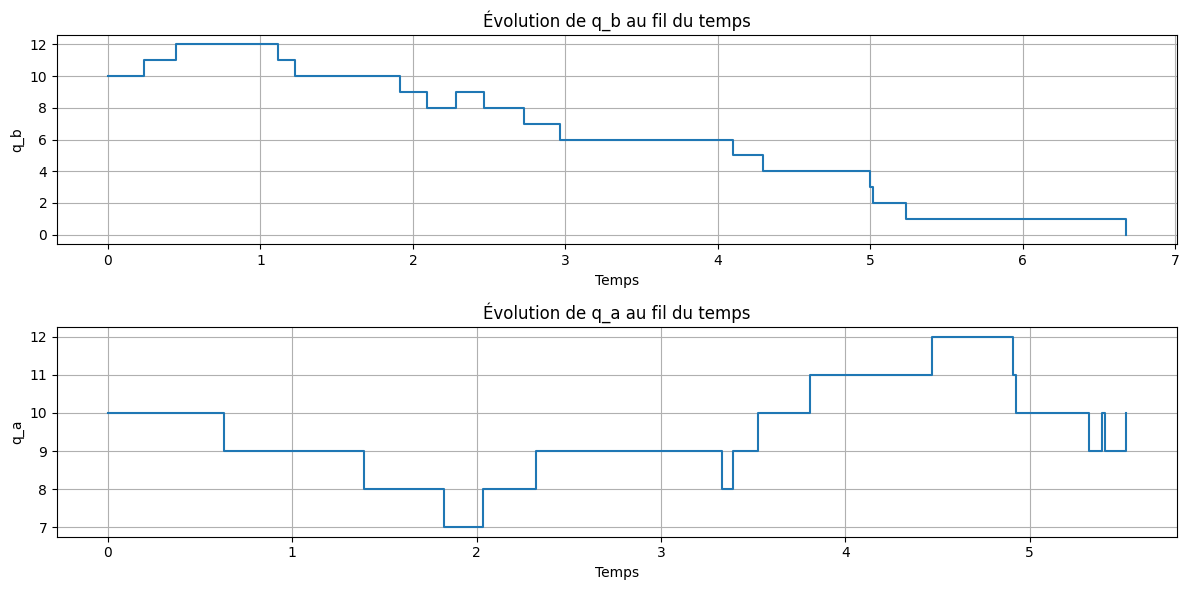

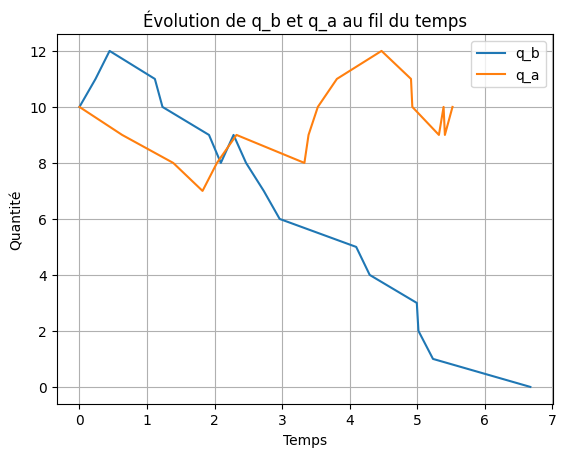

In [21]:
times_b, q_b_values, times_a, q_a_values = simulate_poisson_process_until_zero(LAMBDA_PLUS, LAMBDA_MINUS)
plot_poisson_process(times_b, q_b_values, times_a, q_a_values)
plot_combined(times_b, q_b_values, times_a, q_a_values)

In [22]:
def estimate_time_to_zero(lambda_plus, lambda_minus, q_0_a=Q_0_A, q_0_b=Q_0_B, num_simulations=1000, quantile = 0.95):
    times_to_zero = []
    for _ in range(num_simulations):
        times_b, _, times_a, _ = simulate_poisson_process_until_zero(lambda_plus, lambda_minus, q_0_a, q_0_b)
        times_to_zero.append(max(times_b[-1], times_a[-1]))
    estimate = np.mean(times_to_zero)
    z_score = sps.norm.ppf(1-quantile/2)
    upper_IC_bound = estimate + z_score * np.std(times_to_zero) / np.sqrt(num_simulations)
    lower_IC_bound = estimate - z_score * np.std(times_to_zero) / np.sqrt(num_simulations)
    print (f"Temps moyen estimé pour que q_a ou q_b atteigne zéro : {estimate:.2f} unités de temps")
    print(f"Intervalle de confiance à {quantile*100:.0f}% pour le temps moyen : [{lower_IC_bound}, {upper_IC_bound}]")
    return estimate, lower_IC_bound, upper_IC_bound

def estimate_time_to_zero_for_one_process(lambda_plus, lambda_minus, q_0=Q_0_A, num_simulations=1000, quantile = 0.95):
    times_to_zero = []
    for _ in range(num_simulations):
        q = q_0
        time = 0
        while q > 0:
            total_rate = lambda_plus + lambda_minus
            time_to_next_event = np.random.exponential(1 / total_rate)
            time += time_to_next_event
            if np.random.rand() < lambda_plus / total_rate:
                q += 1
            else:
                q -= 1
        times_to_zero.append(time)
    estimate = np.mean(times_to_zero)
    z_score = sps.norm.ppf(1-quantile/2)
    upper_IC_bound = estimate + z_score * np.std(times_to_zero) / np.sqrt(num_simulations)
    lower_IC_bound = estimate - z_score * np.std(times_to_zero) / np.sqrt(num_simulations)
    print (f"Temps moyen estimé pour que le processus {q_0},{lambda_minus},{lambda_plus} atteigne zéro : {estimate:.2f} unités de temps")
    print(f"Intervalle de confiance à {quantile*100:.0f}% pour le temps moyen du processus {q_0},{lambda_minus},{lambda_plus} : [{lower_IC_bound}, {upper_IC_bound}]")
    return estimate, lower_IC_bound, upper_IC_bound

In [23]:
estimate_time_to_zero(LAMBDA_PLUS, LAMBDA_MINUS, num_simulations=1000, quantile=0.95)
estimate_time_to_zero_for_one_process(LAMBDA_PLUS, LAMBDA_MINUS, num_simulations=1000, quantile=0.95)

Temps moyen estimé pour que q_a ou q_b atteigne zéro : 9.50 unités de temps
Intervalle de confiance à 95% pour le temps moyen : [9.487850622584986, 9.505416677490071]
Temps moyen estimé pour que le processus 10,2,1.2 atteigne zéro : 12.10 unités de temps
Intervalle de confiance à 95% pour le temps moyen du processus 10,2,1.2 : [12.086035118306206, 12.116393866890082]


(np.float64(12.101214492598144),
 np.float64(12.086035118306206),
 np.float64(12.116393866890082))

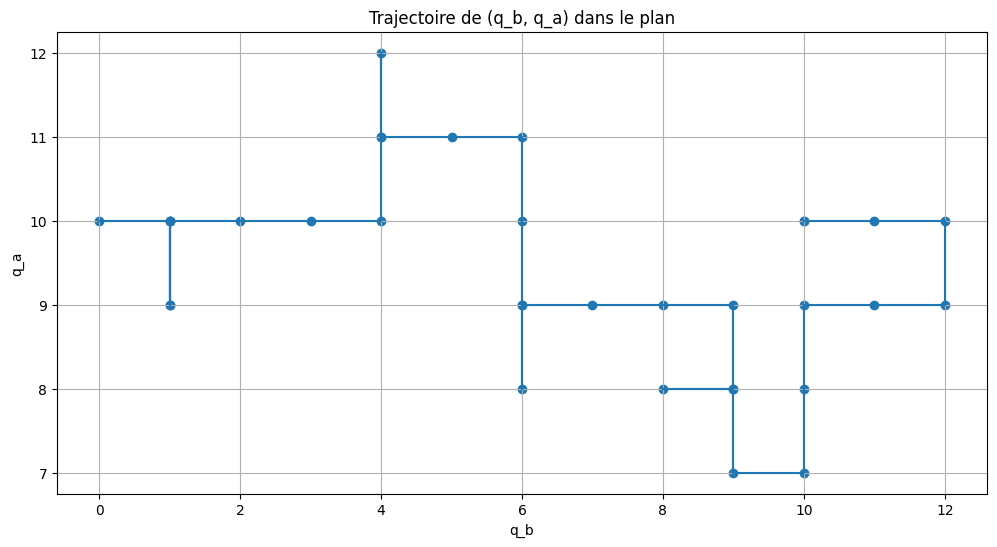

In [24]:
q_A = []
q_B = []
times = np.sort(times_a + times_b)
for t in times:
    q_A.append(q_a_values[times_a.index(t)] if t in times_a else q_A[-1])
    q_B.append(q_b_values[times_b.index(t)] if t in times_b else q_B[-1])
plt.figure(figsize=(12, 6))
plt.scatter(q_B, q_A)  
plt.plot(q_B, q_A)         
plt.title('Trajectoire de (q_b, q_a) dans le plan')
plt.xlabel('q_b')
plt.ylabel('q_a')
plt.grid()
plt.show()